In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Processing disco...
Processing metal...
Processing reggae...
Processing blues...
Processing rock...
Processing classical...
Processing jazz...
Error processing jazz.00054.wav: 
Processing hiphop...
Processing country...
Processing pop...

Training the CNN model...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 238ms/step - accuracy: 0.1211 - loss: 2.3746 - val_accuracy: 0.2950 - val_loss: 2.2072
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2482 - loss: 2.0713 - val_accuracy: 0.3250 - val_loss: 1.9889
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3597 - loss: 1.8364 - val_accuracy: 0.3250 - val_loss: 1.8449
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3417 - loss: 1.7500 - val_accuracy: 0.4300 - val_loss: 1.6771
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4406 - loss: 1.5765 - val_accuracy: 0.4000 - val_loss: 1.6280
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4754 - loss: 1.4799 - val_accuracy: 0.

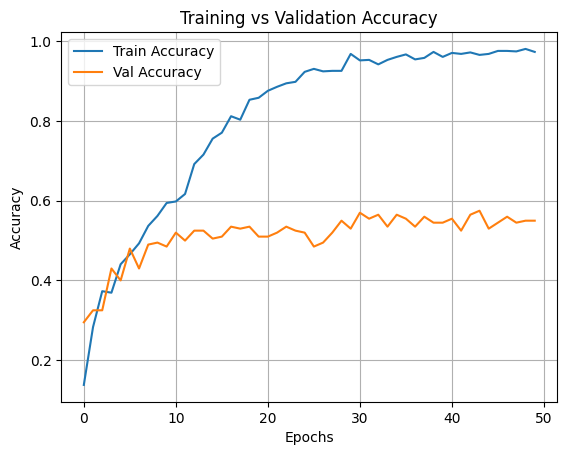

In [6]:
import os
import numpy as np
import librosa
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

warnings.filterwarnings("ignore")

# Constants
DATA_DIR = "/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original"
GENRES = os.listdir(DATA_DIR)
MAX_PAD_LEN = 174  # empirically safe length for 30s MFCC
N_MFCC = 40

# Extract MFCC features
def extract_features(file_path):
    y, sr = librosa.load(file_path)  # load full file
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)

    # Normalize per sample
    mfcc = (mfcc - np.mean(mfcc)) / np.std(mfcc)

    # Pad or truncate to fixed length
    if mfcc.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :MAX_PAD_LEN]

    return mfcc

# Build dataset
X = []
y = []

for genre in GENRES:
    genre_path = os.path.join(DATA_DIR, genre)
    if not os.path.isdir(genre_path):
        continue
    print(f"Processing {genre}...")
    for file in os.listdir(genre_path):
        if file.endswith(".wav"):
            file_path = os.path.join(genre_path, file)
            try:
                mfcc = extract_features(file_path)
                X.append(mfcc)
                y.append(genre)
            except Exception as e:
                print(f"Error processing {file}: {e}")

X = np.array(X)
X = X[..., np.newaxis]  # shape: (samples, 40, 174, 1)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(N_MFCC, MAX_PAD_LEN, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (2, 2), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(len(GENRES), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
print("\nTraining the CNN model...")
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\n✅ CNN Test Accuracy: {acc:.2f}")

# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.grid(True)
plt.show()


In [8]:
# Save the model
model.save('music_genre_classifier.h5')
model.save('music_genre_classifier.keras')

# Save the LabelEncoder (if needed)
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)